Data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("/content/drive/MyDrive/crime_safety_dataset.csv", sep=';')
df.shape, df.head()

((1000, 10),
    id        date      time crime_type          city state  \
 0   1  09/09/2022  18:58:57   Homicide  Philadelphia    PA   
 1   2  10/07/2022  12:10:59    Assault       Phoenix    AZ   
 2   3  31/12/2024  09:26:12   Burglary   San Antonio    TX   
 3   4  12/04/2024  23:17:28  Vandalism  Philadelphia    PA   
 4   5  19/07/2023  04:49:39      Fraud   San Antonio    TX   
 
   location_description  victim_age victim_gender victim_race  
 0        9916 Broadway          34          Male       Other  
 1          6853 Oak St          13        Female       Black  
 2       3760 Maple Ave          23          Male       Asian  
 3         6781 Main St          36         Other       Asian  
 4        3239 Broadway          26         Other       Other  )

**PART I : Risky or not Risky**

Feature and Data cleaning

In [ ]:
import calendar

df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['hour'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour
if df['hour'].isna().mean() > 0.05:
    df['hour'] = pd.to_datetime(df['time'], errors='coerce').dt.hour

df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['month_name'] = df['month'].apply(lambda x: calendar.month_abbr[int(x)] if pd.notna(x) else np.nan)
df[['date','time','hour','dayofweek','month','month_name']].head()


/tmp/ipykernel_176/1482666001.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['hour'] = pd.to_datetime(df['time'], errors='coerce').dt.hour


,date,time,hour,dayofweek,month,month_name
0,2022-09-09,18:58:57,18,4.0,9.0,Sep
1,2022-10-07,12:10:59,12,4.0,10.0,Oct
2,NaT,09:26:12,9,NaN,NaN,NaN
3,2024-12-04,23:17:28,23,2.0,12.0,Dec
4,NaT,04:49:39,4,NaN,NaN,NaN


In [ ]:

df['night'] = df['hour'].apply(lambda x: 1 if x >= 20 or x <= 5 else 0)
df['victim_age'] = df['victim_age'].fillna(df['victim_age'].mean())
df['hour'] = df['hour'].fillna(df['hour'].mean())
df['month'] = df['month'].fillna(df['month'].mean())
df['dayofweek'] = df['dayofweek'].fillna(df['dayofweek'].mean())
df['night'] = df['night'].fillna(df['night'].mean())

df = df.dropna(subset=[
    'state',
    'city',
    'victim_gender',
    'victim_race',
    'crime_type'
])

violent_crimes = ['Assault', 'Robbery', 'Homicide']
df['risky'] = df['crime_type'].apply(lambda x: 1 if x in violent_crimes else 0)

target = 'risky'

features = [
    'state', 'city',
    'month', 'dayofweek', 'hour', 'night',
    'victim_age', 'victim_gender', 'victim_race'
]

df_model = df[features + [target]].copy()

X = df_model[features]
y = df_model[target]

print("Total rows used:", df_model.shape[0])

total = len(df_model)
num_risky = (df_model['risky'] == 1).sum()
num_not_risky = (df_model['risky'] == 0).sum()

print("Risky victims:", num_risky, f"({round(num_risky/total*100,2)}%)")
print("Non-risky victims:", num_not_risky, f"({round(num_not_risky/total*100,2)}%)")

Total rows used: 1000
Risky victims: 299 (29.9%)
Non-risky victims: 701 (70.1%)


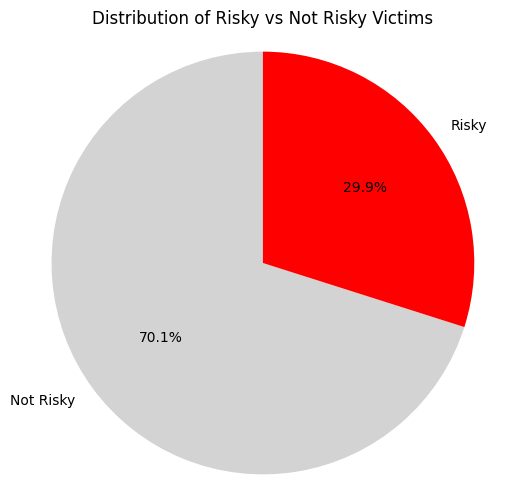

In [ ]:
risky_counts = df_model['risky'].value_counts()

labels = ['Not Risky', 'Risky']
sizes = [risky_counts[0], risky_counts[1]]
colors = ['lightgrey', 'red']

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
plt.title("Distribution of Risky vs Not Risky Victims")
plt.axis('equal')
plt.show()

Split train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 9)
Test set: (200, 9)


**MODEL 1 - RANDOMFOREST**

In [ ]:
cat_cols = ['state', 'city', 'victim_gender', 'victim_race']
num_cols = ['month', 'dayofweek', 'hour', 'night', 'victim_age']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

model = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    class_weight='balanced'
)

clf = Pipeline([
    ('prep', preprocess),
    ('model', model)
])

clf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['state', 'city',
                                                   'victim_gender',
                                                   'victim_race']),
                                                 ('num', 'passthrough',
                                                  ['month', 'dayofweek', 'hour',
                                                   'night', 'victim_age'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=3, n_estimators=500,
                                        random_state=42))])

Model Evaluation + Confusion Matrix



              precision    recall  f1-score   support

   Not Risky       0.73      0.84      0.78       140
       Risky       0.42      0.27      0.33        60

    accuracy                           0.67       200
   macro avg       0.57      0.55      0.55       200
weighted avg       0.64      0.67      0.64       200

RandomForest accuracy: 0.67


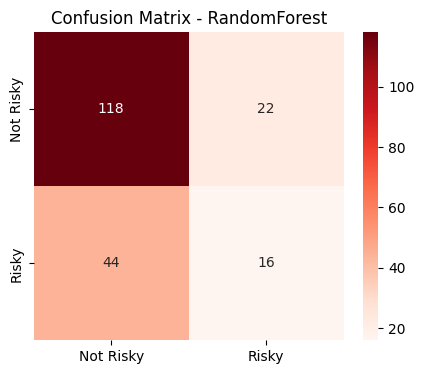

In [ ]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=['Not Risky','Risky']))

rf_accuracy = accuracy_score(y_test, y_pred)
print("RandomForest accuracy:", rf_accuracy)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Not Risky','Risky'],
    yticklabels=['Not Risky','Risky']
)

plt.title("Confusion Matrix - RandomForest")
plt.show()

**MODELE 2 - NEURAL NETWORK (TENSORFLOW)**



GPU check

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


data

In [ ]:
X_tf = pd.get_dummies(df_model[features],drop_first=False)
y_tf = df_model[target].astype(int)

X_train_tf,X_test_tf,y_train_tf,y_test_tf = train_test_split(
    X_tf,y_tf,
    test_size=0.2,
    random_state=42,
    stratify=y_tf
)

scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_tf_scaled = scaler.fit_transform(X_train_tf)
X_test_tf_scaled = scaler.transform(X_test_tf)

network

In [ ]:
model_tf = keras.Sequential([
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

model_tf.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

evaluation

In [ ]:
history = model_tf.fit(
X_train_tf_scaled,
y_train_tf,
validation_split=0.2,
epochs=30,
batch_size=32
)

test_loss,test_acc = model_tf.evaluate(X_test_tf_scaled,y_test_tf)

print("TensorFlow accuracy:",test_acc)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6679 - loss: 0.6300 - val_accuracy: 0.6562 - val_loss: 0.6549
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6792 - loss: 0.6131 - val_accuracy: 0.6625 - val_loss: 0.6446
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6834 - loss: 0.5993 - val_accuracy: 0.6562 - val_loss: 0.6502
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6788 - loss: 0.5857 - val_accuracy: 0.6500 - val_loss: 0.6546
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6830 - loss: 0.5812 - val_accuracy: 0.6687 - val_loss: 0.6574
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7027 - loss: 0.5608 - val_accuracy: 0.6687 - val_loss: 0.6579
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6847 - loss: 0.5721 - val_accuracy: 0.6812 - val_loss: 0.6578
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6974 - loss: 0.5605 - val_accuracy: 0.6625 - val_loss

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
              precision    recall  f1-score   support

   Not Risky       0.72      0.90      0.80       140
       Risky       0.42      0.17      0.24        60

    accuracy                           0.68       200
   macro avg       0.57      0.53      0.52       200
weighted avg       0.63      0.68      0.63       200



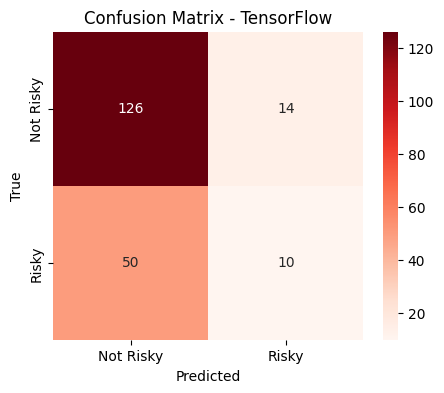

In [ ]:
y_proba_tf = model_tf.predict(X_test_tf_scaled)
y_pred_tf = (y_proba_tf >= 0.5).astype(int).flatten()

print(classification_report(y_test_tf, y_pred_tf, target_names=['Not Risky', 'Risky']))

cm_tf = confusion_matrix(y_test_tf, y_pred_tf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_tf,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Not Risky', 'Risky'],
    yticklabels=['Not Risky', 'Risky']
)

plt.title("Confusion Matrix - TensorFlow")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

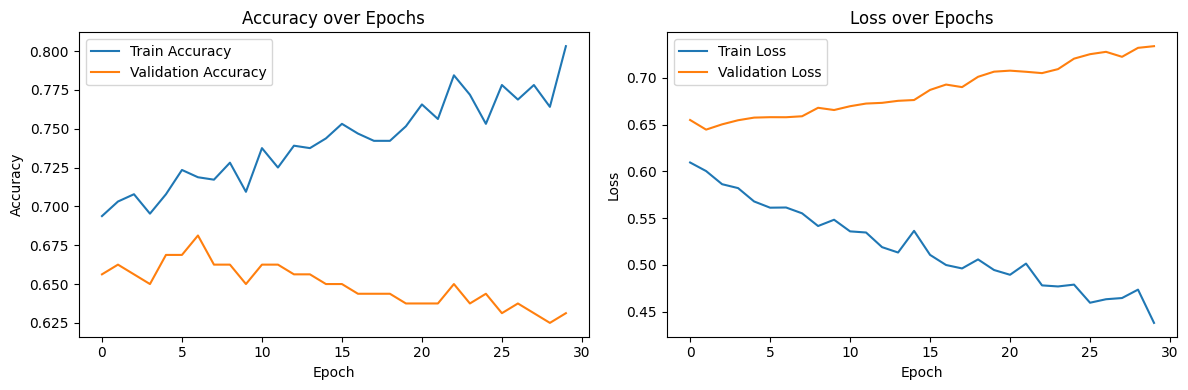

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

MODEL COMPARISON

/tmp/ipykernel_176/2061743429.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models,y=accuracies,palette=['salmon','lightcoral'])


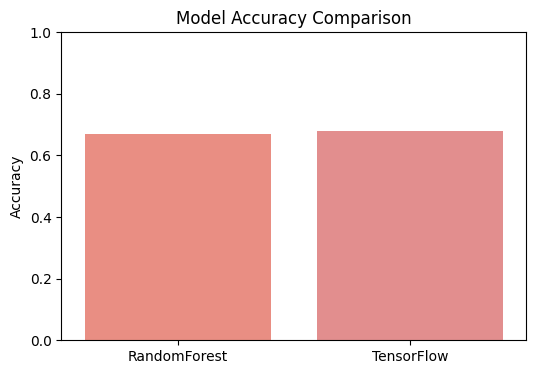

In [ ]:
models = ['RandomForest','TensorFlow']
accuracies = [rf_accuracy,test_acc]

plt.figure(figsize=(6,4))
sns.barplot(x=models,y=accuracies,palette=['salmon','lightcoral'])

plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

**PART II : For high-risk profiles, identify the factors that influence the risk.**

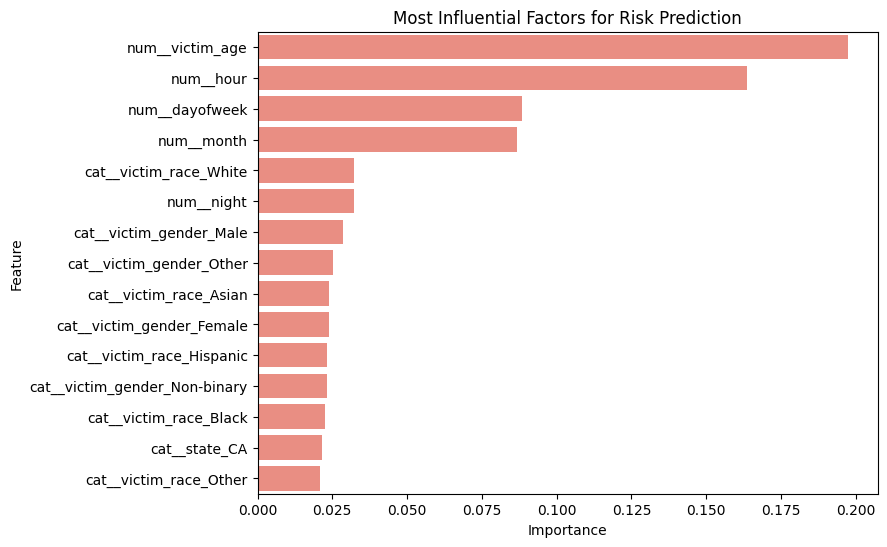

In [ ]:
feature_names = clf.named_steps['prep'].get_feature_names_out()
importances = clf.named_steps['model'].feature_importances_

imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

top_features = imp_df.head(15)

plt.figure(figsize=(8,6))
sns.barplot(
    data=top_features,
    x='importance',
    y='feature',
    color='#FA8072'
)

plt.title("Most Influential Factors for Risk Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# Create age groups
df_model['age_group'] = pd.cut(
    df_model['victim_age'],
    bins=[0,18,30,45,60,100],
    labels=['0-18','19-30','31-45','46-60','60+']
)

# Compute risk percentage per profile
profile_risk = (
    df_model.groupby(['age_group','victim_gender','victim_race'])['risky']
    .agg(['count','mean'])
    .reset_index()
)

profile_risk['risk_percentage'] = (profile_risk['mean'] * 100).round(2)

# Keep profiles with at least 10 observations
profile_risk = profile_risk[profile_risk['count'] >= 10]

# Top 5 risky profiles
top_5_profiles = profile_risk.sort_values(
    by='risk_percentage',
    ascending=False
).head(5)

print("Top 5 victim profiles with the highest risk:")
display(top_5_profiles[['age_group','victim_gender','victim_race','count','risk_percentage']])

Top 5 victim profiles with the highest risk:


/tmp/ipykernel_176/2637197252.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_model.groupby(['age_group','victim_gender','victim_race'])['risky']


,age_group,victim_gender,victim_race,count,risk_percentage
69,46-60,Male,White,11,54.55
20,19-30,Female,Asian,12,50.00
28,19-30,Male,Other,11,45.45
80,60+,Female,Asian,27,44.44
95,60+,Other,Asian,16,43.75


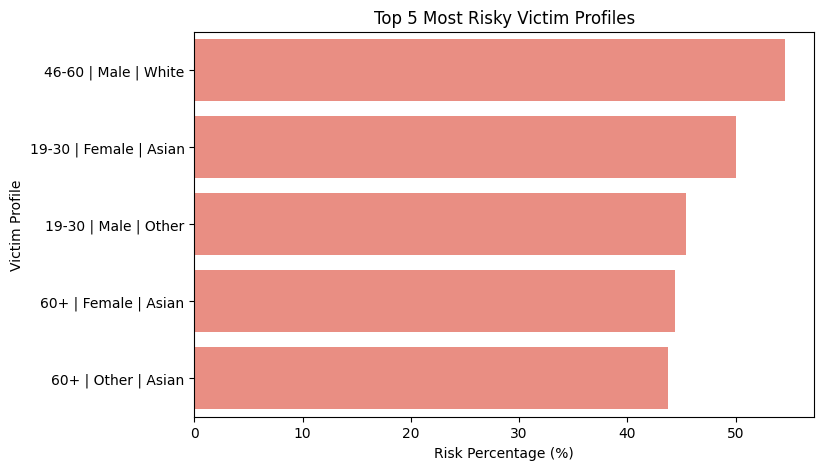

In [ ]:
plt.figure(figsize=(8,5))

profile_labels = (
    top_5_profiles['age_group'].astype(str) + " | " +
    top_5_profiles['victim_gender'] + " | " +
    top_5_profiles['victim_race']
)

sns.barplot(
    x=top_5_profiles['risk_percentage'],
    y=profile_labels,
    color='#FA8072'
)

plt.title("Top 5 Most Risky Victim Profiles")
plt.xlabel("Risk Percentage (%)")
plt.ylabel("Victim Profile")

plt.show()